## Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models

#### Step 1: Identify Business Problem

#### *Business Problem *: The dairy business wants to forecast future monthly milk production so that it can plan inventory, storage, transportation, workforce allocation, and supply chain operations efficiently.

#### Step 2: Define Objective

#### *Objective *:The objective of this project is to build RNN, LSTM, and GRU models to forecast future monthly milk production and compare their performance to identify the best forecasting model.

#### Exploratory Data Analysis (EDA)

In [1]:
##loading dataset
import pandas as pd
df = pd.read_csv('monthly_milk_production.csv')
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [3]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [4]:
##missing values
df.isnull().sum()

Date          0
Production    0
dtype: int64

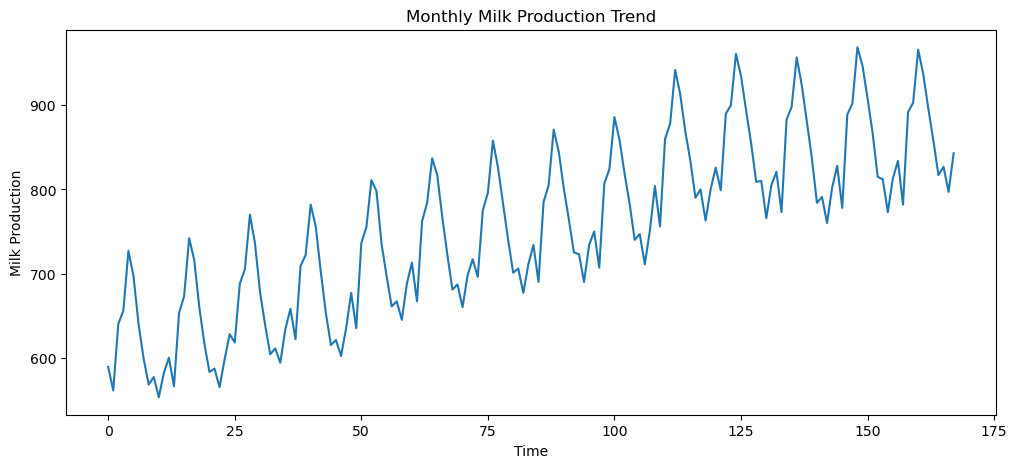

In [5]:
##trend visulaization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.iloc[:,1])
plt.title("Monthly Milk Production Trend")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.show()

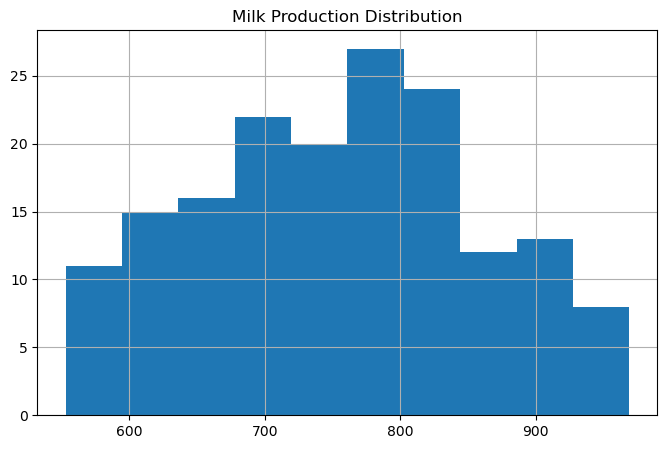

In [6]:
##histogram
df.iloc[:,1].hist(figsize=(8,5))
plt.title("Milk Production Distribution")
plt.show()

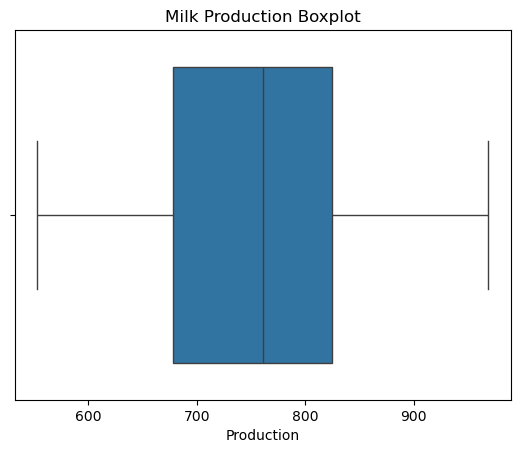

In [7]:
##boxplot
import seaborn as sns
sns.boxplot(x=df.iloc[:,1])
plt.title("Milk Production Boxplot")
plt.show()

#### EDA Interpretation : The time series shows seasonal fluctuations and trend patterns in milk production. Histograms and boxplots help understand data distribution and identify potential outliers.

#### 2.Data Preparation for Deep Learning

In [8]:
##scaling data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(
    df.iloc[:,1].values.reshape(-1,1)
)

In [9]:
#create sequences
import numpy as np
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)
    
window_size = 12
X,y = create_sequences(scaled_data,window_size)

In [10]:
#train-test split
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [11]:
##reshape data
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

#### 3. Model Building

In [17]:
!pip install tensorflow

In [18]:
#Building Basic RNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN

rnn_model = Sequential()
rnn_model.add(
    SimpleRNN(
        50,
        input_shape=(window_size,1)
    )
)

rnn_model.add(Dense(1))
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1741
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0444
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0157
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0113
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0073
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0030
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0025
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0021
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━

In [19]:
#Building LSTM Model
from tensorflow.keras.layers import LSTM
lstm_model = Sequential()
lstm_model.add(
    LSTM(
        50,
        input_shape=(window_size,1)
    )
)

lstm_model.add(Dense(1))
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)
  

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.1444
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0331 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0365
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0240
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0261
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0245
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0240
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0234
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0233 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0230
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0225
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0223
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0220
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0220
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0214
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━

In [20]:
#Building GRU Model
from tensorflow.keras.layers import GRU
gru_model = Sequential()
gru_model.add(
    GRU(
        50,
        input_shape=(window_size,1)
    )
)

gru_model.add(Dense(1))
gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1189
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0328
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0284
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0243
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0221
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0221
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0210
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0206
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0201
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0195
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0192
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0185
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0180
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0181
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0172
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━

#### 4.Model Evaluation

In [21]:
#Predictions
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 752s 752s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step


In [22]:
#Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

def evaluate(y_true,y_pred):
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    )
    return rmse,mae,mape

In [23]:
print("RNN:",evaluate(y_test,rnn_pred))
print("LSTM:",evaluate(y_test,lstm_pred))
print("GRU:",evaluate(y_test,gru_pred))

RNN: (np.float64(0.04041519828003767), 0.03267230881521332, 0.04921842408237251)
LSTM: (np.float64(0.06747519567312385), 0.05739145167171953, 0.08505818507862992)
GRU: (np.float64(0.08007502380926888), 0.06011114412775403, 0.0877708261889035)


In [24]:
#Comparative Analysis
comparison = pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'RMSE':[
        evaluate(y_test,rnn_pred)[0],
        evaluate(y_test,lstm_pred)[0],
        evaluate(y_test,gru_pred)[0]
    ],
    'MAE':[
        evaluate(y_test,rnn_pred)[1],
        evaluate(y_test,lstm_pred)[1],
        evaluate(y_test,gru_pred)[1]
    ],
    'MAPE':[
        evaluate(y_test,rnn_pred)[2],
        evaluate(y_test,lstm_pred)[2],
        evaluate(y_test,gru_pred)[2]
    ]
})
comparison

,Model,RMSE,MAE,MAPE
0,RNN,0.040415,0.032672,0.049218
1,LSTM,0.067475,0.057391,0.085058
2,GRU,0.080075,0.060111,0.087771


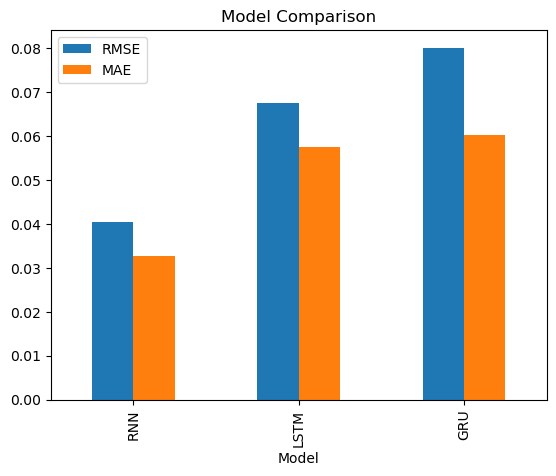

In [25]:
comparison.plot(
    x='Model',
    y=['RMSE','MAE'],
    kind='bar'
)

plt.title("Model Comparison")
plt.show()

#### 5.Prediction and Visualization

In [26]:
#Forecast Next 12 Months
future_predictions = []

current_sequence = X_test[-1]

for i in range(12):

    pred = lstm_model.predict(
        current_sequence.reshape(
            1,
            window_size,
            1
        )
    )

    future_predictions.append(pred[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


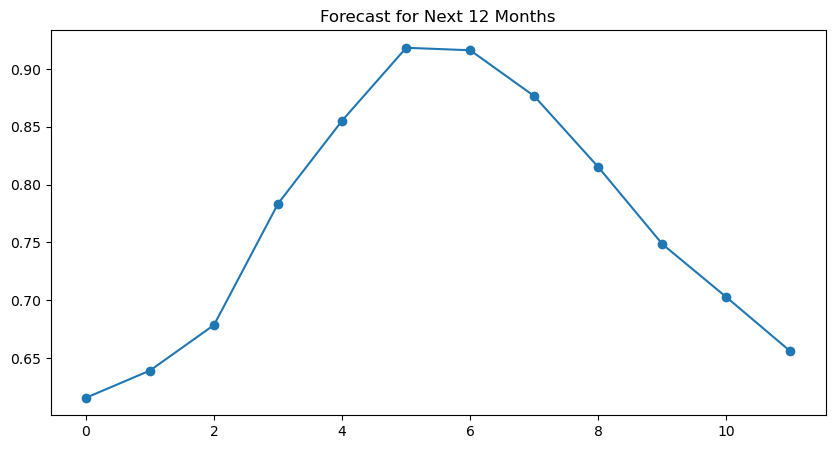

In [27]:
#Plot Forecast
plt.figure(figsize=(10,5))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title(
    "Forecast for Next 12 Months"
)

plt.show()

#### 6.Plot Forecast

##### The forecasting model helps the dairy business estimate future milk production and make informed decisions regarding inventory, storage, transportation, workforce management, and supply chain planning. Accurate forecasts reduce operational risks and improve resource utilization.